In [1]:
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

In [3]:
spark = SparkSession.builder \
    .appName("sparkSQL") \
    .master("local[*]") \
    .config("spark.executors.memory", "512M") \
    .config("spark.executors.core", 4) \
    .config("spark.sql.adaptive.enabled",True)\
    .getOrCreate()

spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/20 10:59:29 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [4]:
emp_schema = """ 
    first_name string,
    last_name string,
    job_title string,
    dob date,
    email string,
    phone string,
    salary float,
    department_id int
"""

emp = spark.read.format("csv").schema(emp_schema).option("header",True).load("/Users/AnhHuynh/Documents/PySpark/employee_records.txt")

In [5]:
dept_schema = """

department_id int,
department_name string,
description string,
city string,
state string,
country string
"""

dept = spark.read.format("csv").schema(dept_schema).option("header",True).load("/Users/AnhHuynh/Documents/PySpark/department_data.txt")

In [6]:
## Spark Catalog

spark.conf.get("spark.sql.catalogImplementation")

'in-memory'

In [8]:
## Show datasets

db = spark.sql("show databases")
db.show()

+---------+
|namespace|
+---------+
|  default|
+---------+



In [25]:
spark.sql("show tables in default").show()

+---------+-------------+-----------+
|namespace|    tableName|isTemporary|
+---------+-------------+-----------+
|  default|     employee|      false|
|         |    dept_view|       true|
|         |emp_temp_view|       true|
|         |     emp_view|       true|
+---------+-------------+-----------+



In [11]:
## Register dataframes as temp views

emp.createOrReplaceTempView("emp_view")

dept.createOrReplaceTempView("dept_view")

In [15]:
## View data from table

emp_filtered = spark.sql("""
    select * from emp_view where salary > 500
    """)

emp_filtered.show()

+----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+
|first_name| last_name|           job_title|       dob|               email|               phone|  salary|department_id|
+----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+
|   Richard|  Morrison|Public relations ...|1973-05-05|melissagarcia@exa...|       (699)525-4827|512653.0|            8|
|     Bobby|  Mccarthy|   Barrister's clerk|1974-04-25|   llara@example.net|  (750)846-1602x7458|999836.0|            7|
|    Dennis|    Norman|Land/geomatics su...|1990-06-24| jturner@example.net|    873.820.0518x825|131900.0|           10|
|      John|    Monroe|        Retail buyer|1968-06-16|  erik33@example.net|    820-813-0557x624|485506.0|            1|
|  Michelle|   Elliott|      Air cabin crew|1975-03-31|tiffanyjohnston@e...|       (705)900-5337|604738.0|            8|
|    Ashley|   Montoya|        C

In [18]:
# Create a new column dob_year and register as temp_view

emp_temp = spark.sql("""
    select e.*, date_format(dob,'yyyy') as dob_year
    from emp_view as e
    """)

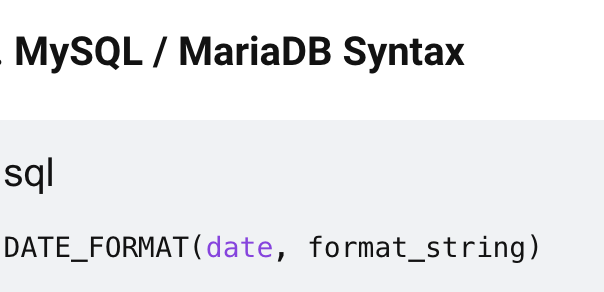

In [19]:
emp_temp.createOrReplaceTempView("emp_temp_view")

In [22]:
## Join emp and dept
employee = spark.sql("""
    select e.*, d.department_name
    from emp_temp_view e
    left join dept_view d on e.department_id = d.department_id
""")

In [23]:
employee.show()

+----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+--------+--------------------+
|first_name| last_name|           job_title|       dob|               email|               phone|  salary|department_id|dob_year|     department_name|
+----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+--------+--------------------+
|   Richard|  Morrison|Public relations ...|1973-05-05|melissagarcia@exa...|       (699)525-4827|512653.0|            8|    1973|          Parker PLC|
|     Bobby|  Mccarthy|   Barrister's clerk|1974-04-25|   llara@example.net|  (750)846-1602x7458|999836.0|            7|    1974|         Ward-Gordon|
|    Dennis|    Norman|Land/geomatics su...|1990-06-24| jturner@example.net|    873.820.0518x825|131900.0|           10|    1990|      Delgado-Keller|
|      John|    Monroe|        Retail buyer|1968-06-16|  erik33@example.net|    820-813-0557x6

* 🫆 Spark SQL hints are optional directives embedded directly into SQL statements to influence how the Catalyst Optimizer structures its execution plan.

* 🧐 When to Use Spark SQL Hints? 
* You should use hints cautiously and only as a last resort. 
* The primary scenarios to use them include:

    * 👵Missing or Outdated Table Statistics: If your data pipeline generates dynamic tables without computing statistics (ANALYZE TABLE), the optimizer might assume a small table is massive and fail to pick a fast broadcast join.

    * 😱Preventing Out-Of-Memory (OOM) Errors: If Spark attempts a Shuffle Hash join on highly skewed keys, a few executors can run out of memory. Forcing a MERGE join can offload memory pressure by utilizing disk sorting.
    
    * 🫟Overriding Small Table Thresholds: If you know a table fits perfectly in executor memory but slightly exceeds the automatic broadcast limit, a BROADCAST hint bypasses this barrier.
    
    * 🗂️Controlling Output File Sizes: When writing SQL results directly to cloud storage or HDFS, you can append a COALESCE or REBALANCE hint to avoid the "small file problem" (creating thousands of tiny files)

#### Code example

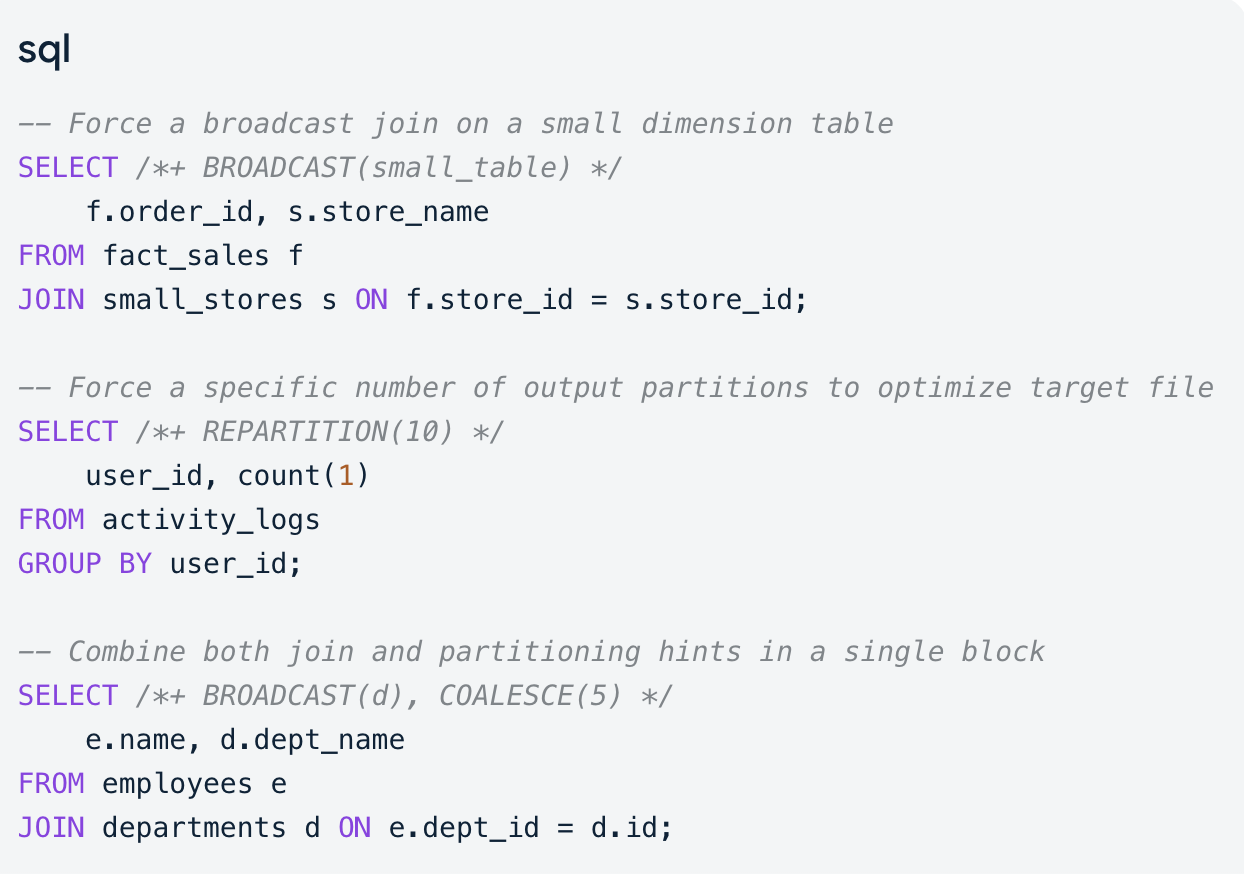

In [24]:
## Write data as table

employee.write.format("parquet").option("header", True).mode("overwrite").option("path", "/Users/AnhHuynh/Documents/PySpark/employee.parquet").saveAsTable("employee")

26/06/20 11:54:02 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers


In [28]:
spark.sql("describe extended employee").show()

+--------------------+--------------------+-------+
|            col_name|           data_type|comment|
+--------------------+--------------------+-------+
|          first_name|              string|   NULL|
|           last_name|              string|   NULL|
|           job_title|              string|   NULL|
|                 dob|                date|   NULL|
|               email|              string|   NULL|
|               phone|              string|   NULL|
|              salary|               float|   NULL|
|       department_id|                 int|   NULL|
|            dob_year|              string|   NULL|
|     department_name|              string|   NULL|
|                    |                    |       |
|# Detailed Table ...|                    |       |
|             Catalog|       spark_catalog|       |
|            Database|             default|       |
|               Table|            employee|       |
|        Created Time|Sat Jun 20 11:54:...|       |
|         La